Iteração 01 | Melhor custo: 23.11
Iteração 02 | Melhor custo: 23.11
Iteração 03 | Melhor custo: 23.11
Iteração 04 | Melhor custo: 23.11
Iteração 05 | Melhor custo: 23.11
Iteração 06 | Melhor custo: 23.11
Iteração 07 | Melhor custo: 23.11
Iteração 08 | Melhor custo: 23.11
Iteração 09 | Melhor custo: 23.11
Iteração 10 | Melhor custo: 23.11
Iteração 11 | Melhor custo: 23.11
Iteração 12 | Melhor custo: 23.11
Iteração 13 | Melhor custo: 23.11
Iteração 14 | Melhor custo: 23.11
Iteração 15 | Melhor custo: 23.11
Iteração 16 | Melhor custo: 23.11
Iteração 17 | Melhor custo: 23.11
Iteração 18 | Melhor custo: 23.11
Iteração 19 | Melhor custo: 23.11
Iteração 20 | Melhor custo: 23.11
Iteração 21 | Melhor custo: 23.11
Iteração 22 | Melhor custo: 23.11
Iteração 23 | Melhor custo: 23.11
Iteração 24 | Melhor custo: 23.11
Iteração 25 | Melhor custo: 23.11
Iteração 26 | Melhor custo: 23.11
Iteração 27 | Melhor custo: 23.11
Iteração 28 | Melhor custo: 23.11
Iteração 29 | Melhor custo: 23.11
Iteração 30 | 

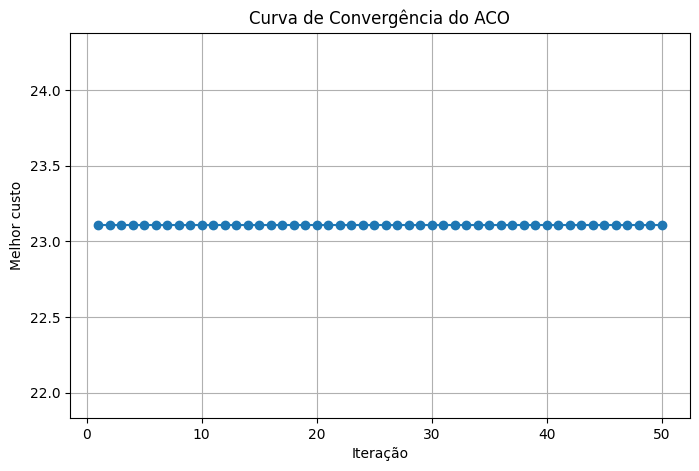


========== FEROMÔNIO FINAL ==========
A -> B: 173.1081
A -> C: 173.1082
A -> D: 0.0002
A -> E: 0.0000
A -> F: 0.0002
B -> A: 173.1081
B -> C: 0.0002
B -> D: 0.0000
B -> E: 0.0027
B -> F: 173.1057
C -> A: 173.1082
C -> B: 0.0002
C -> D: 0.0000
C -> E: 173.1058
C -> F: 0.0025
D -> A: 0.0002
D -> B: 0.0000
D -> C: 0.0000
D -> E: 173.1081
D -> F: 173.1083
E -> A: 0.0000
E -> B: 0.0027
E -> C: 173.1058
E -> D: 173.1081
E -> F: 0.0000
F -> A: 0.0002
F -> B: 173.1057
F -> C: 0.0025
F -> D: 173.1083
F -> E: 0.0000


In [4]:
import random
import math
import matplotlib.pyplot as plt

# ============================================================
# PARÂMETROS DO EXPERIMENTO
# ============================================================

NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100

# ============================================================
# CIDADES
# ============================================================

cidades = {
    "A": (0, 0),
    "B": (2, 4),
    "C": (5, 1),
    "D": (6, 5),
    "E": (8, 2),
    "F": (3, 7)
}

nomes = list(cidades.keys())
NUM_CIDADES = len(nomes)


# ============================================================
# DISTÂNCIA ENTRE DUAS CIDADES
# ============================================================

def distancia(cidade1, cidade2):
    x1, y1 = cidades[cidade1]
    x2, y2 = cidades[cidade2]

    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)


# ============================================================
# MATRIZ DE DISTÂNCIAS
# ============================================================

distancias = {}

for cidade1 in nomes:
    distancias[cidade1] = {}

    for cidade2 in nomes:
        if cidade1 == cidade2:
            distancias[cidade1][cidade2] = 0
        else:
            distancias[cidade1][cidade2] = distancia(cidade1, cidade2)


# ============================================================
# MATRIZ DE FEROMÔNIO
# ============================================================

feromonio = {}

for cidade1 in nomes:
    feromonio[cidade1] = {}

    for cidade2 in nomes:
        if cidade1 == cidade2:
            feromonio[cidade1][cidade2] = 0
        else:
            feromonio[cidade1][cidade2] = 1.0


# ============================================================
# FUNÇÃO PARA CALCULAR O CUSTO DE UMA ROTA
# ============================================================

def calcular_custo(rota):

    custo = 0

    for i in range(len(rota) - 1):
        cidade_atual = rota[i]
        proxima_cidade = rota[i + 1]

        custo += distancias[cidade_atual][proxima_cidade]

    # Retorna para a cidade inicial
    custo += distancias[rota[-1]][rota[0]]

    return custo


# ============================================================
# ESCOLHA DA PRÓXIMA CIDADE
# ============================================================

def escolher_proxima_cidade(cidade_atual, cidades_disponiveis):

    probabilidades = []

    soma = 0

    for cidade in cidades_disponiveis:

        fer = feromonio[cidade_atual][cidade]

        # Quanto menor a distância, maior a atratividade
        heuristica = 1 / distancias[cidade_atual][cidade]

        valor = (fer ** ALPHA) * (heuristica ** BETA)

        probabilidades.append((cidade, valor))

        soma += valor

    # Escolha proporcional à probabilidade
    sorteio = random.uniform(0, soma)

    acumulado = 0

    for cidade, valor in probabilidades:

        acumulado += valor

        if acumulado >= sorteio:
            return cidade

    return probabilidades[-1][0]


# ============================================================
# CONSTRUIR UMA ROTA
# ============================================================

def construir_rota():

    cidade_inicial = random.choice(nomes)

    rota = [cidade_inicial]

    cidades_disponiveis = nomes.copy()

    cidades_disponiveis.remove(cidade_inicial)

    cidade_atual = cidade_inicial

    while cidades_disponiveis:

        proxima_cidade = escolher_proxima_cidade(
            cidade_atual,
            cidades_disponiveis
        )

        rota.append(proxima_cidade)

        cidades_disponiveis.remove(proxima_cidade)

        cidade_atual = proxima_cidade

    return rota


# ============================================================
# EVAPORAÇÃO DO FEROMÔNIO
# ============================================================

def evaporar_feromonio():

    for cidade1 in nomes:

        for cidade2 in nomes:

            if cidade1 != cidade2:

                feromonio[cidade1][cidade2] *= (
                    1 - TAXA_EVAPORACAO
                )


# ============================================================
# DEPÓSITO DE FEROMÔNIO
# ============================================================

def depositar_feromonio(rotas):

    for rota, custo in rotas:

        quantidade = Q / custo

        for i in range(len(rota) - 1):

            cidade1 = rota[i]
            cidade2 = rota[i + 1]

            feromonio[cidade1][cidade2] += quantidade
            feromonio[cidade2][cidade1] += quantidade

        # Última cidade retorna para a primeira
        cidade1 = rota[-1]
        cidade2 = rota[0]

        feromonio[cidade1][cidade2] += quantidade
        feromonio[cidade2][cidade1] += quantidade


# ============================================================
# ALGORITMO ACO
# ============================================================

melhor_rota = None
melhor_custo = float("inf")

historico_melhor_custo = []

for iteracao in range(NUM_ITERACOES):

    rotas = []

    # --------------------------------------------------------
    # CADA FORMIGA CONSTRÓI UMA ROTA
    # --------------------------------------------------------

    for _ in range(NUM_FORMIGAS):

        rota = construir_rota()

        custo = calcular_custo(rota)

        rotas.append((rota, custo))

        # Atualiza a melhor solução encontrada
        if custo < melhor_custo:

            melhor_custo = custo
            melhor_rota = rota.copy()

    # --------------------------------------------------------
    # EVAPORAÇÃO
    # --------------------------------------------------------

    evaporar_feromonio()

    # --------------------------------------------------------
    # DEPÓSITO DE FEROMÔNIO
    # --------------------------------------------------------

    depositar_feromonio(rotas)

    # Guarda o melhor custo encontrado até agora
    historico_melhor_custo.append(melhor_custo)

    print(
        f"Iteração {iteracao + 1:02d} "
        f"| Melhor custo: {melhor_custo:.2f}"
    )


# ============================================================
# RESULTADO DO EXPERIMENTO
# ============================================================

print("\n========== RESULTADO DO EXPERIMENTO ==========")

print("Número de formigas:", NUM_FORMIGAS)
print("Número de iterações:", NUM_ITERACOES)
print("ALPHA:", ALPHA)
print("BETA:", BETA)
print("Taxa de evaporação:", TAXA_EVAPORACAO)
print("Q:", Q)

print("Melhor rota:", " -> ".join(melhor_rota), "->", melhor_rota[0])

print("Melhor custo:", round(melhor_custo, 2))


# ============================================================
# CURVA DE CONVERGÊNCIA
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_ITERACOES + 1),
    historico_melhor_custo,
    marker="o"
)

plt.title("Curva de Convergência do ACO")

plt.xlabel("Iteração")

plt.ylabel("Melhor custo")

plt.grid(True)

plt.show()


# ============================================================
# CONCENTRAÇÃO DO FEROMÔNIO
# ============================================================

print("\n========== FEROMÔNIO FINAL ==========")

for cidade1 in nomes:

    for cidade2 in nomes:

        if cidade1 != cidade2:

            print(
                f"{cidade1} -> {cidade2}: "
                f"{feromonio[cidade1][cidade2]:.4f}"
            )
